In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 14.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import requests
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Lipinski, MACCSkeys
import matplotlib.pyplot as plt
import numpy as np
from rdkit.Chem import MACCSkeys, rdFingerprintGenerator

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, KFold

In [4]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from rdkit.Chem import AllChem, rdMolDescriptors as rdMD
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors as rdMD, AllChem

In [5]:
import json  # lets us work with the json format
import requests  # allows Python to make web requests
import pandas as pd # analysis of tabular data
import rdkit.Chem as chem
from rdkit.Chem import PandasTools

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

In [7]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from rdkit.Chem import AllChem, rdMolDescriptors as rdMD
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors as rdMD, AllChem

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
!ls drive/MyDrive/Colab_Notebooks/lead_discovery/final_assignment/


chembltarget1929.csv		modelo_qsar_final_rf.pkl
filtered_screening_library.csv	pharmacophore_final.ipynb
import_library_screening.ipynb	qsar_final.ipynb
libreria_screening_masiva.csv	Top_100_Candidatos_QSAR.csv


In [11]:

df = pd.read_csv("drive/MyDrive/Colab_Notebooks/lead_discovery/final_assignment/chembltarget1929.csv", sep=";")
df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL5945181,NaN,NaN,324.32,0.0,0.80,BDBM522174,COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1,IC50,'=',...,CHEMBL5728777,37,BindingDB Patent Bioactivity Data,NaN,2021,NaN,NaN,NaN,NaN,6500.0
1,CHEMBL5945181,NaN,NaN,324.32,0.0,0.80,BDBM522174,COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1,k_off,'=',...,CHEMBL5728777,37,BindingDB Patent Bioactivity Data,NaN,2021,NaN,NaN,NaN,NaN,NaN
2,CHEMBL5775947,NaN,NaN,390.36,0.0,1.47,BDBM522180,O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...,IC50,'=',...,CHEMBL5728777,37,BindingDB Patent Bioactivity Data,NaN,2021,NaN,NaN,NaN,NaN,12200.0
3,CHEMBL5775947,NaN,NaN,390.36,0.0,1.47,BDBM522180,O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...,kon,'=',...,CHEMBL5728777,37,BindingDB Patent Bioactivity Data,NaN,2021,NaN,NaN,NaN,NaN,NaN
4,CHEMBL5774747,NaN,NaN,382.26,0.0,0.82,BDBM522181,O=C(Nc1ccc(-c2[nH]nnc2C(F)(F)F)cc1)c1c(O)[nH]c...,kon,'=',...,CHEMBL5728777,37,BindingDB Patent Bioactivity Data,NaN,2021,NaN,NaN,NaN,NaN,NaN


In [12]:
interest_cols = ["Molecule ChEMBL ID", "Smiles", "Standard Type" , "Standard Relation", "Standard Value", "Standard Units"]
df_subset = df[interest_cols]
df_subset

,Molecule ChEMBL ID,Smiles,Standard Type,Standard Relation,Standard Value,Standard Units
0,CHEMBL5945181,COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1,IC50,'=',6500.00,nM
1,CHEMBL5945181,COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1,k_off,'=',NaN,s-1
2,CHEMBL5775947,O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...,IC50,'=',12200.00,nM
3,CHEMBL5775947,O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...,kon,'=',NaN,NaN
4,CHEMBL5774747,O=C(Nc1ccc(-c2[nH]nnc2C(F)(F)F)cc1)c1c(O)[nH]c...,kon,'=',NaN,NaN
...,...,...,...,...,...,...
1956,CHEMBL5979514,CCN(C)c1nc(O)c(C(=O)Nc2ccc(-c3c[nH]nn3)cc2)c(=...,k_off,'=',NaN,s-1
1957,CHEMBL6005655,CSc1nc(O)c(C(=O)Nc2cc(F)c(-c3c[nH]nn3)c(F)c2)c...,IC50,'=',4.30,nM
1958,CHEMBL5814665,CC(C)Sc1nc(O)c(C(=O)Nc2ccc(-c3c[nH]nn3)c(F)c2)...,IC50,'=',0.66,nM
1959,CHEMBL5803335,CC(C)Sc1nc(O)c(C(=O)Nc2ccc(-c3c[nH]nn3)cc2C(F)...,k_off,'=',NaN,s-1


Rename the columns


In [13]:
df_subset= df_subset.rename(columns={"Molecule ChEMBL ID": "molecule_chembl_ID", "Standard Type": "standard_type", "Standard Relation": "standard_relation",
                          "Standard Value": "standard_value", "Standard Units": "standard_units"})

In [14]:
df_subset.columns

Index(['molecule_chembl_ID', 'Smiles', 'standard_type', 'standard_relation',
       'standard_value', 'standard_units'],
      dtype='object')

In [15]:
num_null = df_subset["standard_value"].isna().sum()
num_null
df_subset_clean = df_subset.dropna().reset_index(drop=True)
df_subset_clean.shape

(1292, 6)

In [16]:
df_subset_clean.head()

,molecule_chembl_ID,Smiles,standard_type,standard_relation,standard_value,standard_units
0,CHEMBL5945181,COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1,IC50,'=',6500.0,nM
1,CHEMBL5775947,O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...,IC50,'=',12200.0,nM
2,CHEMBL5997929,O=C(Nc1ccc(-c2nc(C(F)(F)F)n[nH]2)cc1)c1c(O)[nH...,IC50,'=',14500.0,nM
3,CHEMBL5891141,O=C(Nc1ccc(-c2c[nH]nn2)c(C(F)(F)F)c1)c1c(O)[nH...,IC50,'=',2200.0,nM
4,CHEMBL4086701,O=C(/C=C/c1ccc(O)c2oc(-c3ccc(O)c(O)c3)cc12)N[C...,IC50,'=',4510.0,nM


In [17]:
import pandas as pd

def clean_ic50_table(df):
    # Hacemos una copia para no romper el original
    df = df.copy()

    # --- PASO 0: LIMPIEZA DE "BASURA" INVISIBLE ---
    # 1. Quitamos espacios en blanco al principio y final de los textos (ej: "nM " -> "nM")
    # 2. Quitamos comillas simples que a veces se cuelan (ej: "'='" -> "=")
    cols_texto = ["standard_type", "standard_relation", "standard_units"]

    for col in cols_texto:
        if col in df.columns:
            # Convertimos a string, quitamos espacios (strip) y quitamos comillas (' y ")
            df[col] = df[col].astype(str).str.strip().str.replace("'", "").str.replace('"', '')

    # --- AHORA SÍ, APLICAMOS TUS FILTROS ---

    # 1. Dejar solo IC50
    df = df[df["standard_type"] == "IC50"]

    # 2. Convertir valores numéricos
    df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")

    # 3. Quitar NaNs y valores negativos/cero
    df = df[df["standard_value"] > 0]

    # 4. Filtrar por relación '=' (Ahora ya funcionará porque hemos limpiado las comillas)
    df = df[df["standard_relation"] == "="]

    # 5. Filtrar unidades 'nM'
    df = df[df["standard_units"] == "nM"]

    return df

# --- PRUEBA ---
clean_activity = clean_ic50_table(df_subset_clean)

print(f"Filas recuperadas: {len(clean_activity)}")
print(clean_activity.head())

Filas recuperadas: 808
  molecule_chembl_ID                                             Smiles  \
0      CHEMBL5945181      COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1   
1      CHEMBL5775947  O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...   
2      CHEMBL5997929  O=C(Nc1ccc(-c2nc(C(F)(F)F)n[nH]2)cc1)c1c(O)[nH...   
3      CHEMBL5891141  O=C(Nc1ccc(-c2c[nH]nn2)c(C(F)(F)F)c1)c1c(O)[nH...   
4      CHEMBL4086701  O=C(/C=C/c1ccc(O)c2oc(-c3ccc(O)c(O)c3)cc12)N[C...   

  standard_type standard_relation  standard_value standard_units  
0          IC50                 =          6500.0             nM  
1          IC50                 =         12200.0             nM  
2          IC50                 =         14500.0             nM  
3          IC50                 =          2200.0             nM  
4          IC50                 =          4510.0             nM  


In [18]:
clean_activity

,molecule_chembl_ID,Smiles,standard_type,standard_relation,standard_value,standard_units
0,CHEMBL5945181,COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1,IC50,=,6500.000,nM
1,CHEMBL5775947,O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...,IC50,=,12200.000,nM
2,CHEMBL5997929,O=C(Nc1ccc(-c2nc(C(F)(F)F)n[nH]2)cc1)c1c(O)[nH...,IC50,=,14500.000,nM
3,CHEMBL5891141,O=C(Nc1ccc(-c2c[nH]nn2)c(C(F)(F)F)c1)c1c(O)[nH...,IC50,=,2200.000,nM
4,CHEMBL4086701,O=C(/C=C/c1ccc(O)c2oc(-c3ccc(O)c(O)c3)cc12)N[C...,IC50,=,4510.000,nM
...,...,...,...,...,...,...
1286,CHEMBL5970628,CSc1nc(O)c(C(=O)Nc2ccc(-c3c[nH]nn3)nc2)c(=O)[nH]1,IC50,=,0.377,nM
1287,CHEMBL4101163,COC(=O)[C@H](Cc1ccc(O)cc1)NC(=O)/C=C/c1ccc(O)c...,IC50,=,47250.000,nM
1289,CHEMBL5765459,CSc1nc(O)c(C(=O)Nc2ccc(-c3c[nH]nn3)cc2C#N)c(=O...,IC50,=,0.040,nM
1290,CHEMBL6005655,CSc1nc(O)c(C(=O)Nc2cc(F)c(-c3c[nH]nn3)c(F)c2)c...,IC50,=,4.300,nM


In [19]:
num_null_after = clean_activity.isna().sum()
num_null_after

,0
molecule_chembl_ID,0
Smiles,0
standard_type,0
standard_relation,0
standard_value,0
standard_units,0


In [20]:
#  Contamos cuántos duplicados hay basándonos en la columna 'Smiles'
print(f"Duplicados antes: {clean_activity['Smiles'].duplicated().sum()}")

#  ELIMINAMOS duplicados del DataFrame COMPLETO, mirando solo la columna 'Smiles'

final_df = clean_activity.drop_duplicates(subset=['Smiles']).reset_index(drop=True)

# Verificamos que ya no queden
print(f"Duplicados después: {final_df['Smiles'].duplicated().sum()}")

# Mostramos el resultado
final_df


Duplicados antes: 154
Duplicados después: 0


,molecule_chembl_ID,Smiles,standard_type,standard_relation,standard_value,standard_units
0,CHEMBL5945181,COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1,IC50,=,6500.000,nM
1,CHEMBL5775947,O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...,IC50,=,12200.000,nM
2,CHEMBL5997929,O=C(Nc1ccc(-c2nc(C(F)(F)F)n[nH]2)cc1)c1c(O)[nH...,IC50,=,14500.000,nM
3,CHEMBL5891141,O=C(Nc1ccc(-c2c[nH]nn2)c(C(F)(F)F)c1)c1c(O)[nH...,IC50,=,2200.000,nM
4,CHEMBL4086701,O=C(/C=C/c1ccc(O)c2oc(-c3ccc(O)c(O)c3)cc12)N[C...,IC50,=,4510.000,nM
...,...,...,...,...,...,...
649,CHEMBL6023080,O=c1[nH]c(=O)c2c(Nc3ccc(-c4cnn[nH]4)cc3)n[nH]c...,IC50,=,140.000,nM
650,CHEMBL5970628,CSc1nc(O)c(C(=O)Nc2ccc(-c3c[nH]nn3)nc2)c(=O)[nH]1,IC50,=,0.377,nM
651,CHEMBL5765459,CSc1nc(O)c(C(=O)Nc2ccc(-c3c[nH]nn3)cc2C#N)c(=O...,IC50,=,0.040,nM
652,CHEMBL6005655,CSc1nc(O)c(C(=O)Nc2cc(F)c(-c3c[nH]nn3)c(F)c2)c...,IC50,=,4.300,nM


MODEL PREPARATION

In [21]:
from numpy import log10
import numpy as np
# 2. Convertir nM a Molar
molar_conc = final_df['standard_value'] * 1e-9

# 3. Calcular pIC50
final_df['pIC50'] = -np.log10(molar_conc)

Crear una class que determine si una molecula es activa o no en funcion de su valor pIC50, no hay un valor establecido, pero bueno en foros he leido que sobre 300 asi qu sera mas o menos un valor d pic50 de 6.5

In [22]:
final_df["class"] = final_df["pIC50"].apply(lambda x : 1 if x > 6.3 else 0)
final_df.head()

,molecule_chembl_ID,Smiles,standard_type,standard_relation,standard_value,standard_units,pIC50,class
0,CHEMBL5945181,COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1,IC50,=,6500.0,nM,5.187087,0
1,CHEMBL5775947,O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...,IC50,=,12200.0,nM,4.913640,0
2,CHEMBL5997929,O=C(Nc1ccc(-c2nc(C(F)(F)F)n[nH]2)cc1)c1c(O)[nH...,IC50,=,14500.0,nM,4.838632,0
3,CHEMBL5891141,O=C(Nc1ccc(-c2c[nH]nn2)c(C(F)(F)F)c1)c1c(O)[nH...,IC50,=,2200.0,nM,5.657577,0
4,CHEMBL4086701,O=C(/C=C/c1ccc(O)c2oc(-c3ccc(O)c(O)c3)cc12)N[C...,IC50,=,4510.0,nM,5.345823,0


In [23]:
counts = final_df["class"].value_counts()
counts

,count
class,
0,350
1,304


luego veo donde meto esto class_weight='balanced'

In [24]:
balanced_df = final_df.copy()


Adddddd descriptors


In [25]:
# Convert SMILES to Mol
balanced_df["Mol"] = balanced_df["Smiles"].apply(Chem.MolFromSmiles)
# Compute classical molecular descriptors 2D
balanced_df["MW"] = balanced_df["Mol"].apply(Descriptors.MolWt)
balanced_df["LogP"] = balanced_df["Mol"].apply(Descriptors.MolLogP)
balanced_df["TPSA"] = balanced_df["Mol"].apply(Descriptors.TPSA)
balanced_df["HBA"] = balanced_df["Mol"].apply(Lipinski.NumHAcceptors)
balanced_df["HBD"] = balanced_df["Mol"].apply(Lipinski.NumHDonors)
balanced_df["AromaticRings"] = balanced_df["Mol"].apply(Lipinski.NumAromaticRings)
balanced_df["FractionCSP3"] = balanced_df["Mol"].apply(Lipinski.FractionCSP3)
balanced_df["RotBonds"] = balanced_df["Mol"].apply(Lipinski.NumRotatableBonds)
balanced_df["HeavyAtoms"] = balanced_df["Mol"].apply(Descriptors.HeavyAtomCount)
balanced_df["RingCount"] = balanced_df["Mol"].apply(Descriptors.RingCount)
balanced_df["MolMR"] = balanced_df["Mol"].apply(Descriptors.MolMR)
balanced_df["MaxAbsPartial"] = balanced_df["Mol"].apply(Descriptors.MaxAbsPartialCharge)
balanced_df["MaxPartialCharge"] = balanced_df["Mol"].apply(Descriptors.MaxPartialCharge)
balanced_df["MinAbsPartial"]= balanced_df["Mol"].apply(Descriptors.MinAbsPartialCharge)
balanced_df["MinPartialCharge"] = balanced_df["Mol"].apply(Descriptors.MinPartialCharge)

In [26]:
def smile_fingerprint(mol, method ="maccs", n_bits=2048):
  """
    Encode a molecule from a mol string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.

  """
  if method == "maccs":
      return np.array(MACCSkeys.GenMACCSKeys(mol))
  if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetFingerprint(mol))
  if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetFingerprint(mol))

In [27]:
completed_df = balanced_df.copy()
#completed_df["FP"] = completed_df["Mol"].apply(smile_fingerprint("morgan2"))
#completed_df.head(3)
#we can apply different methods, in this case morgan 2
# : Usamos lambda para pasar el argumento 'method'
completed_df["FP"] = completed_df["Mol"].apply(lambda x: smile_fingerprint(x, method="morgan2"))

#check
print(completed_df.head(3))

  molecule_chembl_ID                                             Smiles  \
0      CHEMBL5945181      COc1ccc([N+](=O)[O-])c(S(=O)(=O)CCc2cnccn2)n1   
1      CHEMBL5775947  O=C(Nc1ccc(-c2[nH]nnc2-c2ccccc2)cc1)c1c(O)[nH]...   
2      CHEMBL5997929  O=C(Nc1ccc(-c2nc(C(F)(F)F)n[nH]2)cc1)c1c(O)[nH...   

  standard_type standard_relation  standard_value standard_units     pIC50  \
0          IC50                 =          6500.0             nM  5.187087   
1          IC50                 =         12200.0             nM  4.913640   
2          IC50                 =         14500.0             nM  4.838632   

   class                                               Mol       MW  ...  \
0      0  <rdkit.Chem.rdchem.Mol object at 0x789e11555700>  324.318  ...   
1      0  <rdkit.Chem.rdchem.Mol object at 0x789e11557610>  390.359  ...   
2      0  <rdkit.Chem.rdchem.Mol object at 0x789e11556420>  382.258  ...   

   FractionCSP3  RotBonds  HeavyAtoms  RingCount     MolMR  MaxAbsPartial  \
0   

# ML


In [28]:
#Build the list with the descriptor im going to use for the model prediction
descriptor_cols = [
     'MW', 'LogP', 'TPSA',	'HBA',	'HBD', "AromaticRings", "FractionCSP3", "RotBonds", "HeavyAtoms", "RingCount",
     "MolMR", "MaxAbsPartial", "MaxPartialCharge",
     "MinAbsPartial", "MinPartialCharge"
]

In [29]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt




#  Convertir Descriptores a Matriz (rellenando posibles huecos con 0)

existing_cols = [c for c in descriptor_cols if c in completed_df.columns]
X_desc = completed_df[existing_cols].fillna(0).values

# 3. Convertir Fingerprints a Matriz
# Usamos .tolist() para sacar los arrays de la columna de Pandas
X_fp = np.array(completed_df['FP'].tolist())

# 4. UNIR AMBOS MUNDOS (Concatenación Horizontal)
X_final = np.hstack((X_desc, X_fp))
y = completed_df['class'].values

print(f"Dimensiones de Descriptores: {X_desc.shape}")
print(f"Dimensiones de Fingerprints: {X_fp.shape}")
print(f"Dimensiones TOTALES (X):     {X_final.shape}")

Dimensiones de Descriptores: (654, 15)
Dimensiones de Fingerprints: (654, 2048)
Dimensiones TOTALES (X):     (654, 2063)


In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
len(X_train)

523

In [32]:
len(X_test)

131

I plot the distribution of the train and test set, so i can check that is well uniform

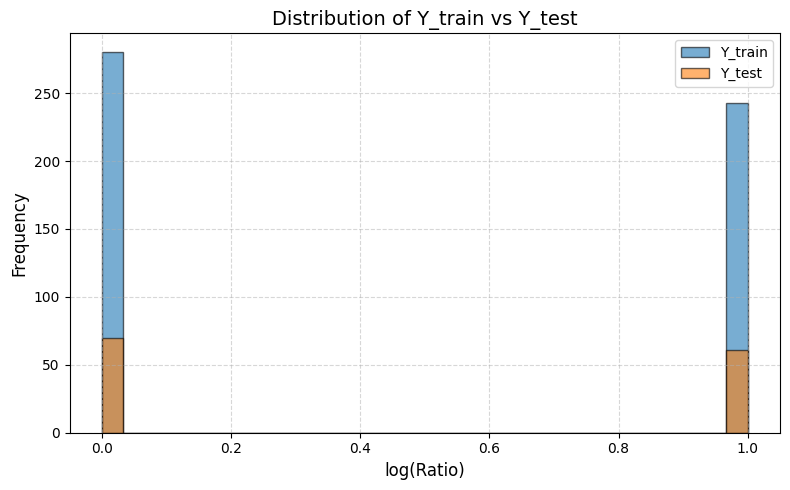

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(Y_train, bins=30, alpha=0.6, label='Y_train', edgecolor='black')
plt.hist(Y_test,  bins=30, alpha=0.6, label='Y_test',  edgecolor='black')

plt.xlabel('log(Ratio)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Y_train vs Y_test', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Parámetros para Clasificación
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],      # Reducir profundidad evita overfitting
    "max_features": ["sqrt"],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "bootstrap": [True],
    "criterion": ["gini", "entropy"]
}

# StratifiedKFold es vital para datos desbalanceados
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Modelo con balanceo de clases
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

# GridSearch
model = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=cv,
    scoring="roc_auc", # Métrica clave en QSAR
    n_jobs=-1,
    verbose=1 # Para ver el progreso
)

# Entrenar (GridSearch ya hace el fit con Cross-Validation)
model.fit(X_train, Y_train)

# Resultados
print("Mejores hiperparámetros:", model.best_params_)
print("Mejor ROC AUC en CV:", model.best_score_)

# Evaluación Final
best_model_rf = model.best_estimator_
# No hace falta volver a hacer .fit(), best_estimator_ ya está entrenado con todo X_train

pred = best_model_rf.predict(X_test)
probs = best_model_rf.predict_proba(X_test)[:, 1] # Probabilidad para AUC

print("\n--- Evaluación final ---")
print(classification_report(Y_test, pred))
print("Test ROC AUC:", roc_auc_score(Y_test, probs))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores hiperparámetros: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor ROC AUC en CV: 0.9479295736151603

--- Evaluación final ---
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        70
           1       0.85      0.82      0.83        61

    accuracy                           0.85       131
   macro avg       0.85      0.85      0.85       131
weighted avg       0.85      0.85      0.85       131

Test ROC AUC: 0.9230679156908665


In [36]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score

# 1. Grid de parámetros (ligeramente diferente para HistGradient)
params = {
    "learning_rate": [0.01, 0.1],
    "max_iter": [100, 200],         # Equivale a n_estimators
    "max_depth": [3, 5, None],      # None permite que el algoritmo decida
    "l2_regularization": [0, 0.1],  # Ayuda a evitar overfitting
    "max_leaf_nodes": [31]          # Valor por defecto típico
}

# 2. Cross validation (Estratificado)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Modelo (Soporta NaNs nativamente)
# class_weight='balanced' está disponible en versiones recientes de scikit-learn para este modelo
hgbm = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')

# 4. GridSearch
model_hgbm = GridSearchCV(
    estimator=hgbm,
    param_grid=params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# 5. Entrenar
print("Iniciando búsqueda con HistGradientBoosting...")
model_hgbm.fit(X_train, Y_train)

print("Mejores hiperparámetros:", model_hgbm.best_params_)
print("Mejor ROC AUC en CV:", model_hgbm.best_score_)

# 6. Evaluación Final
best_model = model_hgbm.best_estimator_
pred = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

print("\n--- Evaluación final (HistGradientBoosting) ---")
print(classification_report(Y_test, pred))
print("Test ROC AUC:", roc_auc_score(Y_test, probs))

Iniciando búsqueda con HistGradientBoosting...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros: {'l2_regularization': 0.1, 'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 100, 'max_leaf_nodes': 31}
Mejor ROC AUC en CV: 0.9284605806608358

--- Evaluación final (HistGradientBoosting) ---
              precision    recall  f1-score   support

           0       0.84      0.89      0.86        70
           1       0.86      0.80      0.83        61

    accuracy                           0.85       131
   macro avg       0.85      0.84      0.85       131
weighted avg       0.85      0.85      0.85       131

Test ROC AUC: 0.9283372365339578


## Screening

Load the library for the qsar screening

In [37]:
df_library = pd.read_csv("drive/MyDrive/Colab_Notebooks/lead_discovery/final_assignment/filtered_screening_library.csv", sep = ",")

In [38]:
df_library.head()

,chembl_id,smiles
0,CHEMBL6329,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl
1,CHEMBL6328,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1
2,CHEMBL265667,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1
3,CHEMBL6362,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1
4,CHEMBL267864,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1


In [41]:
df_library.shape

(46353, 2)

In [42]:
duplicates_rows = df_library["smiles"].duplicated().sum()
duplicates_rows
df_library_clean = df_library.drop_duplicates(subset=['smiles']).reset_index(drop=True)

In [43]:
def calcular_descriptores(df):

    df['Mol'] = df['smiles'].apply(Chem.MolFromSmiles)

    # Calcular las 15 propiedades
    df["MW"] = df["Mol"].apply(Descriptors.MolWt)
    df["LogP"] = df["Mol"].apply(Descriptors.MolLogP)
    df["TPSA"] = df["Mol"].apply(Descriptors.TPSA)
    df["HBA"] = df["Mol"].apply(Lipinski.NumHAcceptors)
    df["HBD"] = df["Mol"].apply(Lipinski.NumHDonors)
    df["AromaticRings"] = df["Mol"].apply(Lipinski.NumAromaticRings)
    df["FractionCSP3"] = df["Mol"].apply(Lipinski.FractionCSP3)
    df["RotBonds"] = df["Mol"].apply(Lipinski.NumRotatableBonds)
    df["HeavyAtoms"] = df["Mol"].apply(Descriptors.HeavyAtomCount)
    df["RingCount"] = df["Mol"].apply(Descriptors.RingCount)
    df["MolMR"] = df["Mol"].apply(Descriptors.MolMR)
    df["MaxAbsPartial"] = df["Mol"].apply(Descriptors.MaxAbsPartialCharge)
    df["MaxPartialCharge"] = df["Mol"].apply(Descriptors.MaxPartialCharge)
    df["MinAbsPartial"]= df["Mol"].apply(Descriptors.MinAbsPartialCharge)
    df["MinPartialCharge"] = df["Mol"].apply(Descriptors.MinPartialCharge)

    return df

# Aplicamos la función
df_screening = calcular_descriptores(df_library_clean)

In [44]:
def smile_fingerprint(smiles, method ="maccs", n_bits=2048):
  """
    Encode a molecule from a mol string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.

  """

  # convert smiles to RDKit mol object
  mol = Chem.MolFromSmiles(smiles)

  if method == "maccs":
      return np.array(MACCSkeys.GenMACCSKeys(mol))
  if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetFingerprint(mol))
  if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetFingerprint(mol))

In [45]:

df_screen_final = df_screening.copy()
#same as before with lambda function
df_screen_final["FP"] = df_screening["smiles"].apply(lambda x: smile_fingerprint(x, method="morgan2"))

#check
print(df_screen_final.head(3))

      chembl_id                                            smiles  \
0    CHEMBL6329      Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl   
1    CHEMBL6328   Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1   
2  CHEMBL265667  Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1   

                                                Mol       MW     LogP    TPSA  \
0  <rdkit.Chem.rdchem.Mol object at 0x789e01561620>  341.754  2.11362   84.82   
1  <rdkit.Chem.rdchem.Mol object at 0x789e0162b060>  332.319  1.33190  108.61   
2  <rdkit.Chem.rdchem.Mol object at 0x789e08af0820>  357.797  2.27274   87.98   

   HBA  HBD  AromaticRings  FractionCSP3  RotBonds  HeavyAtoms  RingCount  \
0    5    1              3      0.058824         3          24          3   
1    6    1              3      0.055556         3          25          3   
2    5    2              3      0.166667         3          25          3   

     MolMR  MaxAbsPartial  MaxPartialCharge  MinAbsPartial  MinPartialCharge  \
0  90.076

In [49]:

X_desc_screen = df_screen_final[descriptor_cols].fillna(0).values

# 3. Convertir Fingerprints a Matriz
# Usamos .tolist() para sacar los arrays de la columna de Pandas
X_fp_screen = np.array(df_screen_final['FP'].tolist())

# 4. UNIR AMBOS MUNDOS (Concatenación Horizontal)
X_final_screen = np.hstack((X_desc_screen, X_fp_screen))


print(f"Dimensiones de Descriptores: {X_desc_screen.shape}")
print(f"Dimensiones de Fingerprints: {X_fp_screen.shape}")
print(f"Dimensiones TOTALES (X):     {X_final_screen.shape}")

Dimensiones de Descriptores: (46353, 15)
Dimensiones de Fingerprints: (46353, 2048)
Dimensiones TOTALES (X):     (46353, 2063)


In [47]:
predicciones = best_model_rf.predict(X_final_screen)
probabilidades = best_model_rf.predict_proba(X_final_screen)[:, 1]

In [48]:

df_screening['Prediccion_Activo'] = predicciones
df_screening['Probabilidad_Activo'] = probabilidades

In [50]:
df_screening

,chembl_id,smiles,Mol,MW,LogP,TPSA,HBA,HBD,AromaticRings,FractionCSP3,RotBonds,HeavyAtoms,RingCount,MolMR,MaxAbsPartial,MaxPartialCharge,MinAbsPartial,MinPartialCharge,Prediccion_Activo,Probabilidad_Activo
0,CHEMBL6329,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl,<rdkit.Chem.rdchem.Mol object at 0x789e01561620>,341.754,2.11362,84.82,5,1,3,0.058824,3,24,3,90.0762,0.349058,0.349058,0.288546,-0.288546,0,0.415
1,CHEMBL6328,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1,<rdkit.Chem.rdchem.Mol object at 0x789e0162b060>,332.319,1.33190,108.61,6,1,3,0.055556,3,25,3,89.7812,0.349058,0.349058,0.288605,-0.288605,0,0.490
2,CHEMBL265667,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1,<rdkit.Chem.rdchem.Mol object at 0x789e08af0820>,357.797,2.27274,87.98,5,2,3,0.166667,3,25,3,95.4425,0.383640,0.349058,0.349058,-0.383640,0,0.390
3,CHEMBL6362,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1,<rdkit.Chem.rdchem.Mol object at 0x789e0148e490>,307.309,1.46022,84.82,5,1,3,0.058824,3,23,3,85.0662,0.349058,0.349058,0.288616,-0.288616,0,0.325
4,CHEMBL267864,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1,<rdkit.Chem.rdchem.Mol object at 0x789e0148dbd0>,341.754,2.11362,84.82,5,1,3,0.058824,3,24,3,90.0762,0.349058,0.349058,0.288605,-0.288605,0,0.425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46348,CHEMBL313754,CC(=O)OCC1=C(C(=O)OC(C)(C)C)N2C(=O)[C@H](OC=O)...,<rdkit.Chem.rdchem.Mol object at 0x789e00fb4120>,389.382,-0.71640,133.35,9,0,0,0.600000,5,26,2,84.8618,0.461220,0.355230,0.355230,-0.461220,0,0.230
46349,CHEMBL313625,CCCC(NC(=O)OCc1ccccc1)C(=O)N[C@H](Cc1c[nH]c2cc...,<rdkit.Chem.rdchem.Mol object at 0x789e00fb4190>,452.511,2.79570,132.55,5,5,3,0.291667,10,33,3,122.3213,0.444676,0.407621,0.407621,-0.444676,0,0.195
46350,CHEMBL314394,COc1ccc(C2=NN(C(C)(C)C)C(=O)C3CCCCC23)cc1OC,<rdkit.Chem.rdchem.Mol object at 0x789e00fb4200>,344.455,3.85500,51.13,4,0,1,0.600000,3,25,3,98.1300,0.492870,0.246449,0.246449,-0.492870,0,0.355
46351,CHEMBL82389,CCCNc1c(C(=O)OCC)cnc2c1cnn2CC(Cl)c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x789e00fb4270>,386.883,4.41000,69.04,6,1,3,0.350000,8,27,3,107.3012,0.462294,0.341342,0.341342,-0.462294,0,0.260


In [52]:
cols_final = ["chembl_id", "smiles", "Prediccion_Activo", "Probabilidad_Activo" ]
df_final_qsar = df_screening[cols_final]
df_final_qsar

,chembl_id,smiles,Prediccion_Activo,Probabilidad_Activo
0,CHEMBL6329,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl,0,0.415
1,CHEMBL6328,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1,0,0.490
2,CHEMBL265667,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1,0,0.390
3,CHEMBL6362,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1,0,0.325
4,CHEMBL267864,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1,0,0.425
...,...,...,...,...
46348,CHEMBL313754,CC(=O)OCC1=C(C(=O)OC(C)(C)C)N2C(=O)[C@H](OC=O)...,0,0.230
46349,CHEMBL313625,CCCC(NC(=O)OCc1ccccc1)C(=O)N[C@H](Cc1c[nH]c2cc...,0,0.195
46350,CHEMBL314394,COc1ccc(C2=NN(C(C)(C)C)C(=O)C3CCCCC23)cc1OC,0,0.355
46351,CHEMBL82389,CCCNc1c(C(=O)OCC)cnc2c1cnn2CC(Cl)c1ccccc1,0,0.260


In [53]:
df_actives = df_final_qsar[df_final_qsar['Prediccion_Activo'] == 1]
df_actives

,chembl_id,smiles,Prediccion_Activo,Probabilidad_Activo
166,CHEMBL6296,CN(C)c1cccc2c(S(=O)(=O)Nc3ncc(Br)nc3C#N)cccc12,1,0.525
489,CHEMBL7083,C/C(=C\Cn1oc(=O)[nH]c1=O)c1cccc(OCc2noc(-c3ccc...,1,0.515
1095,CHEMBL7853,CC(C)(C)NCC(O)COc1ccc(NC(=O)c2cccs2)cc1C#N,1,0.620
1435,CHEMBL8800,Cn1nnnc1C(=C\c1ccc(F)cc1)/C=C/C(O)CC(O)CC(=O)[...,1,0.520
1437,CHEMBL8886,Cn1nnnc1C(/C=C/C(O)CC(O)CC(=O)[O-])=C/c1ccc(F)...,1,0.520
...,...,...,...,...
45509,CHEMBL81686,O=C(NNc1ccccc1)c1ccc2ccc(C(=O)O)c(O)c2n1,1,0.505
45573,CHEMBL83490,COc1cc2ncc(C#N)c(Nc3cc(OC)c(OC)c(OC)c3Br)c2cc1OC,1,0.510
45718,CHEMBL82058,Cc1c(F)c(Oc2cccc(C(=N)N)c2)nc(Oc2cc(N(C)C)ccc2...,1,0.555
46165,CHEMBL82744,O=C(O)c1ccccc1C(=O)c1ccc(Oc2ccccc2)c([N+](=O)[...,1,0.530


In [54]:
# 1. Ordenar todo el DataFrame por la columna 'Probabilidad_Activo' de mayor a menor
#    (Asegúrate de que 'df_screening' es el nombre de tu tabla de resultados)
df_ordenado = df_actives.sort_values(by='Probabilidad_Activo', ascending=False)



In [55]:
import os

# 1. Definir la ruta de tu carpeta en Drive
# (Esta es la misma ruta donde tenías tu archivo chembltarget1929.csv)
ruta_carpeta = '/content/drive/MyDrive/Colab_Notebooks/lead_discovery/final_assignment/'

# 2. Definir el nombre del archivo
nombre_archivo = 'filtered_Candidatos_QSAR.csv'

# 3. Crear la ruta completa (Carpeta + Nombre del archivo)
ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)

# 4. Guardar
# index=False es importante para que no se guarde una columna extra con los números 0, 1, 2...
df_ordenado.to_csv(ruta_completa, index=False)

print(f"¡Listo! Archivo guardado en: {ruta_completa}")

¡Listo! Archivo guardado en: /content/drive/MyDrive/Colab_Notebooks/lead_discovery/final_assignment/filtered_Candidatos_QSAR.csv
